In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit
from src.analyze_cic_ids import nre_classification, flow_based_classification
from src.classification_tools import plot_roc_curves

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'  # 'Monday-WorkingHours.pcap_ISCX.csv' #  Wednesday-workingHours.pcap_ISCX.csv
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)

(445645, 85)


In [3]:
np.unique(df[' Label'].values, return_counts= True)

(array(['BENIGN', 'FTP-Patator', 'SSH-Patator'], dtype=object),
 array([431813,   7935,   5897], dtype=int64))

In [2]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle)
len(entity_names)

13

In [3]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle: #105
    subnet_names = pickle.load(handle) 
len(subnet_names)

141

Conditioning number:  1322703914849054.5 
Determinant of F^T*F:  -1.007921861068307e-17


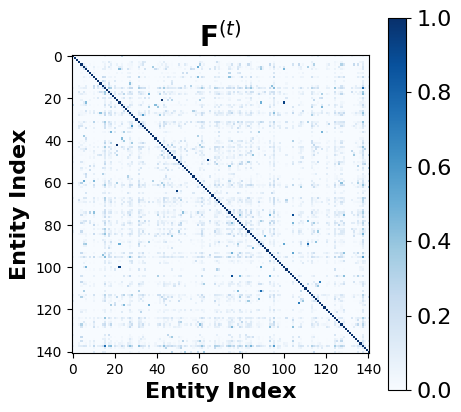

<Figure size 640x480 with 0 Axes>

In [5]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=subnet_names,
             window_type= 'time', sync_window_size= 20, time_scale= 'sec')

cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

In [8]:


#models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Trees': DecisionTreeClassifier(),
#          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}
models = {'Decision Trees': DecisionTreeClassifier(), #'Logistic Regression': LogisticRegression(),
          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

labelling_opt = 'attacks first'
conn_param = 'NPR'#'Num Packets Rec'
feat_cols = (' Total Fwd Packets', ' Total Backward Packets')

nre_curves = {}
df_nre = nre_classification(df, models, entity_names=subnet_names, t_graph=90,
                            conn_param=conn_param, sync_window_size=1.2, verbose=True, roc_curves=nre_curves, seed=30)
print(df_nre)

1
Current time and samples shape:  2017-04-07 01:02:00 (75, 141)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 141)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 141)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 141)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 141)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 141)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 141)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 141)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 141)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 141)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 141)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 141)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 141)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 141)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 141)
16
Current time and

In [9]:
import importlib
import src.classification_tools

importlib.reload(src.classification_tools)
from src.classification_tools import *

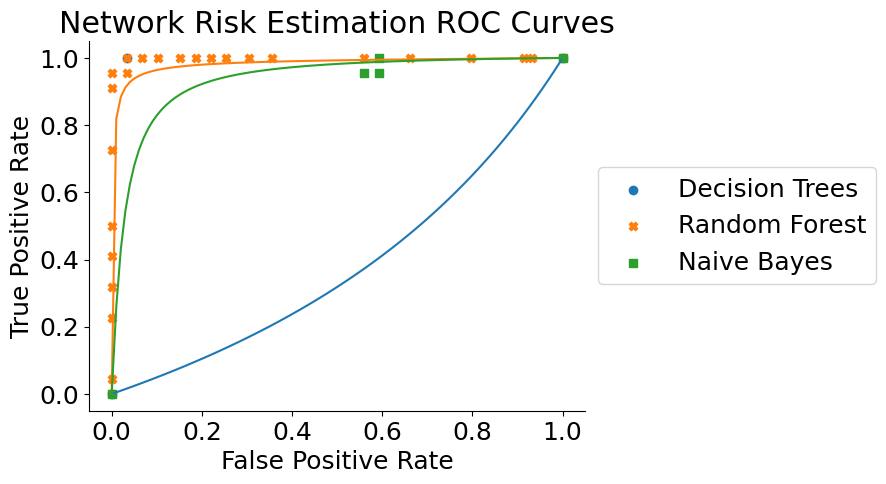

In [10]:
fig1 = plot_roc_curves(nre_curves, title='Network Risk Estimation ROC Curves')

In [20]:
import importlib
import src.classification_tools

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import *

In [21]:
len(entity_names), len(subnet_names)

(13, 141)

In [63]:
names = subnet_names
idx = df[' Source IP'].isin(names) & df[' Destination IP'].isin(names)
df_filt = df[idx].copy()

In [64]:
df[df[' Label'] != 'BENIGN']

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
68410,192.168.10.8-205.174.165.73-53966-444-6,192.168.10.8,53966,205.174.165.73,444,6,2017-06-07 02:19:00,2030,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
66383,192.168.10.8-205.174.165.73-53966-444-6,192.168.10.8,53966,205.174.165.73,444,6,2017-06-07 02:19:00,42664070,5,6,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
72581,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:28:00,119991834,5523,5525,...,20,997842.0,831471.3076,1585781.0,409903.0,8143987.5,1821773.648,9432176.0,6855799.0,Infiltration
75039,192.168.10.8-205.174.165.73-54131-444-6,192.168.10.8,54131,205.174.165.73,444,6,2017-06-07 02:30:00,119974830,3398,3398,...,20,824363.0,0.0,824363.0,824363.0,9785751.0,0.0,9785751.0,9785751.0,Infiltration
73090,192.168.10.8-205.174.165.73-54122-444-6,192.168.10.8,54122,205.174.165.73,444,6,2017-06-07 02:30:00,5005212,15,15,...,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
73634,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:30:00,119973135,4376,4374,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
78192,192.168.10.8-205.174.165.73-54131-444-6,192.168.10.8,54131,205.174.165.73,444,6,2017-06-07 02:32:00,118573317,3733,3732,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
77580,192.168.10.8-205.174.165.73-54573-444-6,192.168.10.8,54573,205.174.165.73,444,6,2017-06-07 02:32:00,78233714,48,52,...,20,2024843.8,3093999.209,7461188.0,3051.0,13600000.0,10200000.0,29500000.0,5662979.0,Infiltration
77445,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:32:00,119993844,3813,3811,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
82330,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:34:00,119992821,2252,2250,...,20,34300000.0,11400000.0,42400000.0,26200000.0,19400000.0,15500000.0,30300000.0,8400626.0,Infiltration


In [65]:
df_filt[df_filt[' Label'] != 'BENIGN']

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label


In [59]:
feat_cols = ('Active Mean', ' Flow Duration', 'Flow Bytes/s', ' Fwd Header Length', ' Bwd Header Length',
                     'Idle Mean', ' act_data_pkt_fwd', ' Total Fwd Packets', ' Total Backward Packets', ' Fwd IAT Mean',
                     ' Bwd IAT Mean', ' Fwd Packet Length Mean', ' Bwd Packet Length Mean', ' Source Port',
                     ' Destination Port', ' Protocol', ' Bwd IAT Mean', ' Fwd IAT Mean')
feat_cols = (' Flow Duration', )#(' Total Fwd Packets', ' Total Backward Packets')
models = {'Decision Trees': DecisionTreeClassifier(), #'Logistic Regression': LogisticRegression(),
          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

flow_based_curves = {}
df_flow_based = flow_based_classification(df, models, t_graph=180, entity_names= entity_names,# sub_net_size=.5,# entity_names=subnet_names,
                                          feat_cols = feat_cols, roc_curves=flow_based_curves, seed=138) #32
print(df_flow_based)

                Accuracy  Precision  Recall  Balanced Accuracy   f1
Decision Trees  0.333333   0.333333     1.0                0.5  0.5
Random Forest   0.333333   0.333333     1.0                0.5  0.5
Naive Bayes     0.666667   0.000000     0.0                0.5  0.0


C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\src\analyze_cic_ids.py:310: UserWarning: Reported results are not fully representative since thresholding is not implemented for the flow_based_classification function directly. Use the roc_curves parameters to gauge the performance instead.
  warnings.warn('Reported results are not fully representative since thresholding is not implemented for the ' +


In [60]:
flow_based_curves

{'Decision Trees': (array([0.        , 0.        , 0.        , 0.16666667, 0.16666667,
         1.        ]),
  array([0.        , 0.11111111, 0.88888889, 0.88888889, 1.        ,
         1.        ])),
 'Random Forest': (array([0.        , 0.        , 0.        , 0.05555556, 0.05555556,
         0.16666667, 0.16666667, 1.        ]),
  array([0.        , 0.11111111, 0.77777778, 0.77777778, 0.88888889,
         0.88888889, 1.        , 1.        ])),
 'Naive Bayes': (array([0., 1.]), array([0., 1.]))}

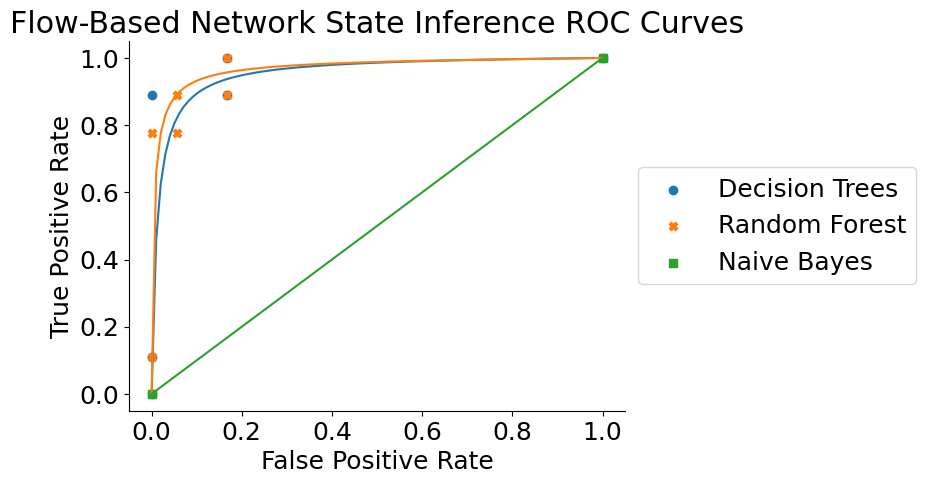

In [61]:
fig2 = plot_roc_curves(flow_based_curves, title='Flow-Based Network State Inference ROC Curves')

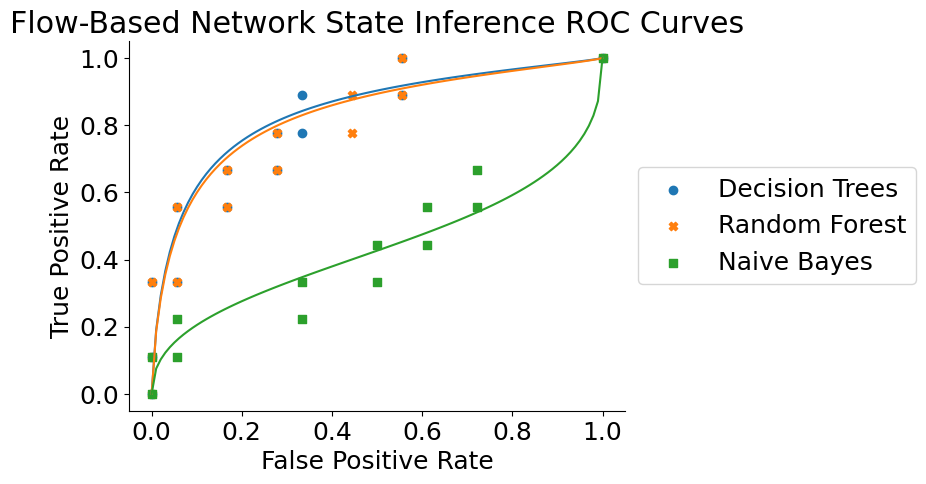

In [55]:
fig2 = plot_roc_curves(flow_based_curves, title='Flow-Based Network State Inference ROC Curves')

In [18]:
import importlib
import src.classification_tools

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import *

In [4]:
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'  # 'Monday-WorkingHours.pcap_ISCX.csv' #  Wednesday-workingHours.pcap_ISCX.csv
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv' # 36 Attacks only
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)

C:\Users\bayer\AppData\Local\Temp\ipykernel_12308\2558213033.py:7: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')


(170231, 85)


In [5]:
from src.analyze_cic_ids import compare_among_conn_params

conn_params = ['NPS', 'NPR'] # 

all_df, roc_curves = compare_among_conn_params(df, entity_names_nre=subnet_names, entity_names_fb=entity_names,# sub_net_size=.9,
                                               control=True,t_graph=180, sync_window_size=1.2, best_op_point=True, seed=138, #32
                                               forget_factor=0.5, relief_factor=0.2)#, conn_params=conn_params, models=models)

All features:  [' Bwd Header Length', ' Bwd IAT Mean', ' Bwd Packet Length Mean', ' Destination Port', ' Flow Duration', ' Fwd Header Length', ' Fwd IAT Mean', ' Fwd Packet Length Mean', ' Protocol', ' Source Port', ' Total Backward Packets', ' Total Fwd Packets', ' act_data_pkt_fwd', 'Active Mean', 'Flow Bytes/s', 'Idle Mean']


 23%|████████████████████████████████████████████▌                                                                                                                                                    | 3/13 [03:48<12:55, 77.55s/it]C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
 46%|█████████████████████████████████████████████████████████████████████████████████████████                                                                                                        | 6/13 [08:35<10:37, 91.05s/it]C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_divis

In [6]:
import pickle

with open(r'saves\sweep_thursday_web_180_1_2_control_all_two.pickle', 'wb') as handle:
    pickle.dump(all_df, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
with open(r'saves\sweep_thursday_web_180_1_2_control_all.pickle', 'rb') as handle:
    all_df = pickle.load(handle)

In [12]:
all_df 

,Balanced Accuracy,Connection Parameter,Classifier,Method
0,0.703401,Number of Packets Sent,Decision Trees,FBNSI
1,0.707116,Number of Packets Sent,Random Forest,FBNSI
2,0.563957,Number of Packets Sent,Naive Bayes,FBNSI
3,0.421393,Number of Packets Sent,Decision Trees,NRE
4,0.772764,Number of Packets Sent,Random Forest,NRE
...,...,...,...,...
112,0.849329,Idle Time,Random Forest,NRE
113,0.454825,Idle Time,Naive Bayes,NRE
114,0.915470,Idle Time,Decision Trees,FBNSI Control
115,0.847990,Idle Time,Random Forest,FBNSI Control


..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


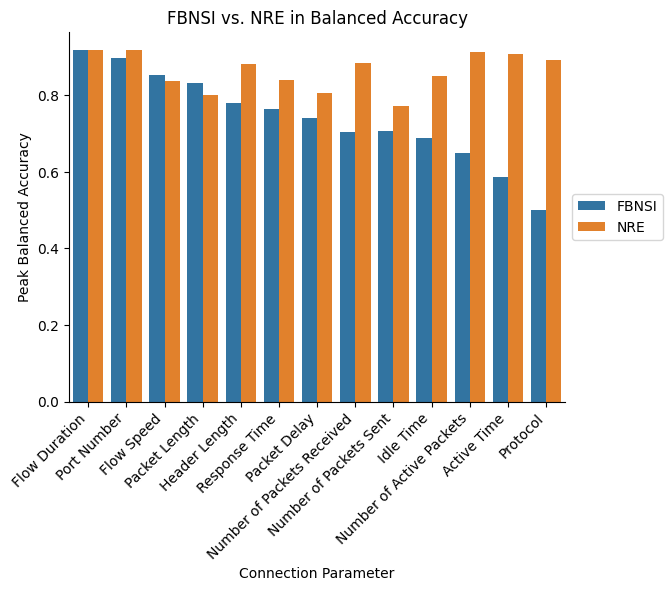

In [13]:
from src.analyze_cic_ids import plot_perf_comparison

fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True, hue_order=['FBNSI', 'NRE'],
                          order=['Flow Duration', 'Port Number' ,'Flow Speed', 'Packet Length', 'Header Length', 'Response Time', 'Packet Delay',
                                 'Number of Packets Received', 'Number of Packets Sent', 'Idle Time', 'Number of Active Packets',
                                 'Active Time', 'Protocol'])#, 'FBNSI Control'])
print(file_addr)

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


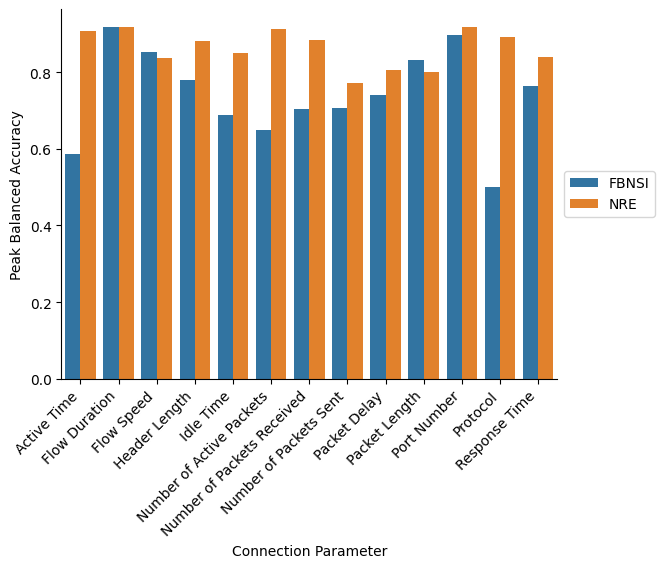

In [8]:
from src.analyze_cic_ids import plot_perf_comparison

fig = plot_perf_comparison(all_df, title='', peak_only=True, hue_order=['FBNSI', 'NRE'])
print(file_addr)

In [32]:
roc_curves

{'Decision Trees': (array([0., 1.]), array([nan, nan])),
 'Random Forest': (array([0., 1.]), array([nan, nan])),
 'Naive Bayes': (array([0., 1.]), array([nan, nan]))}

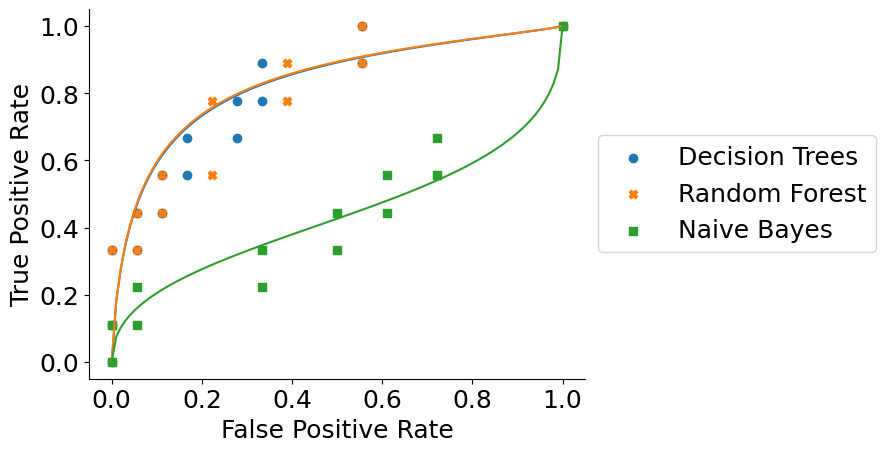

In [58]:
fig3 = plot_roc_curves(roc_curves, title='')

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


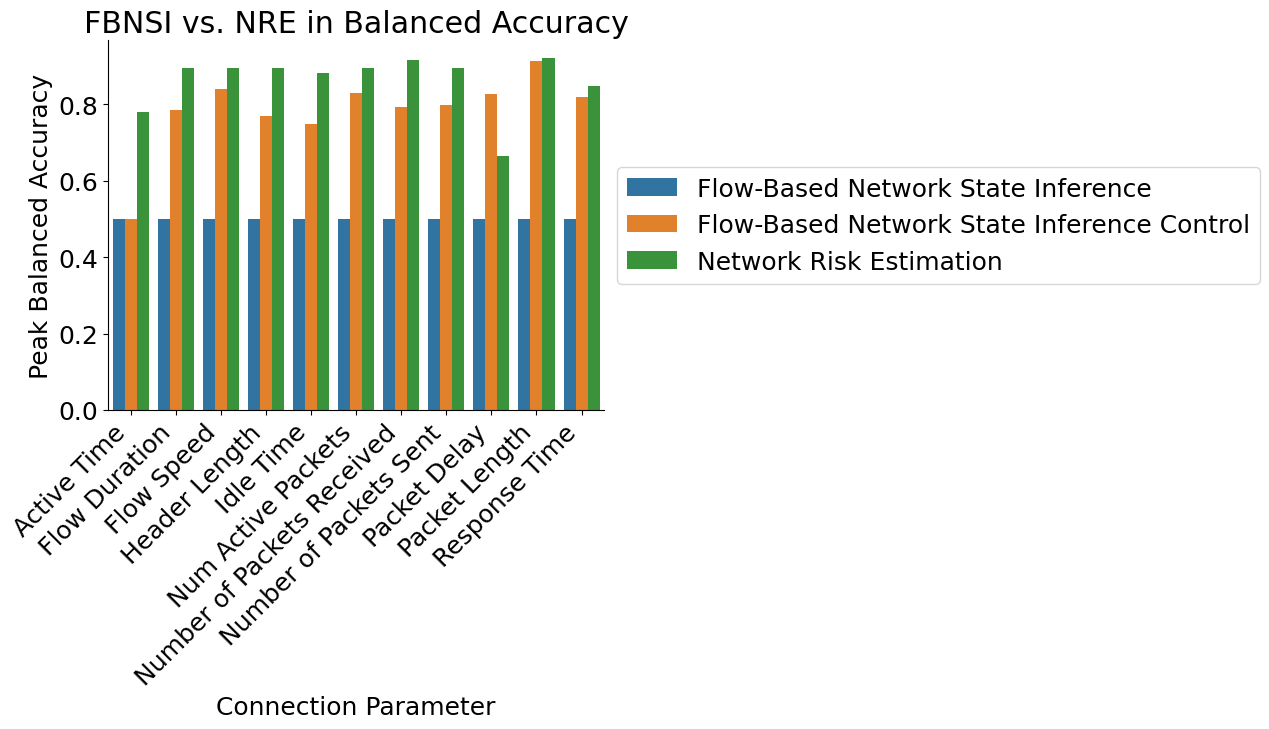

In [150]:
fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True)
print(file_addr)

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


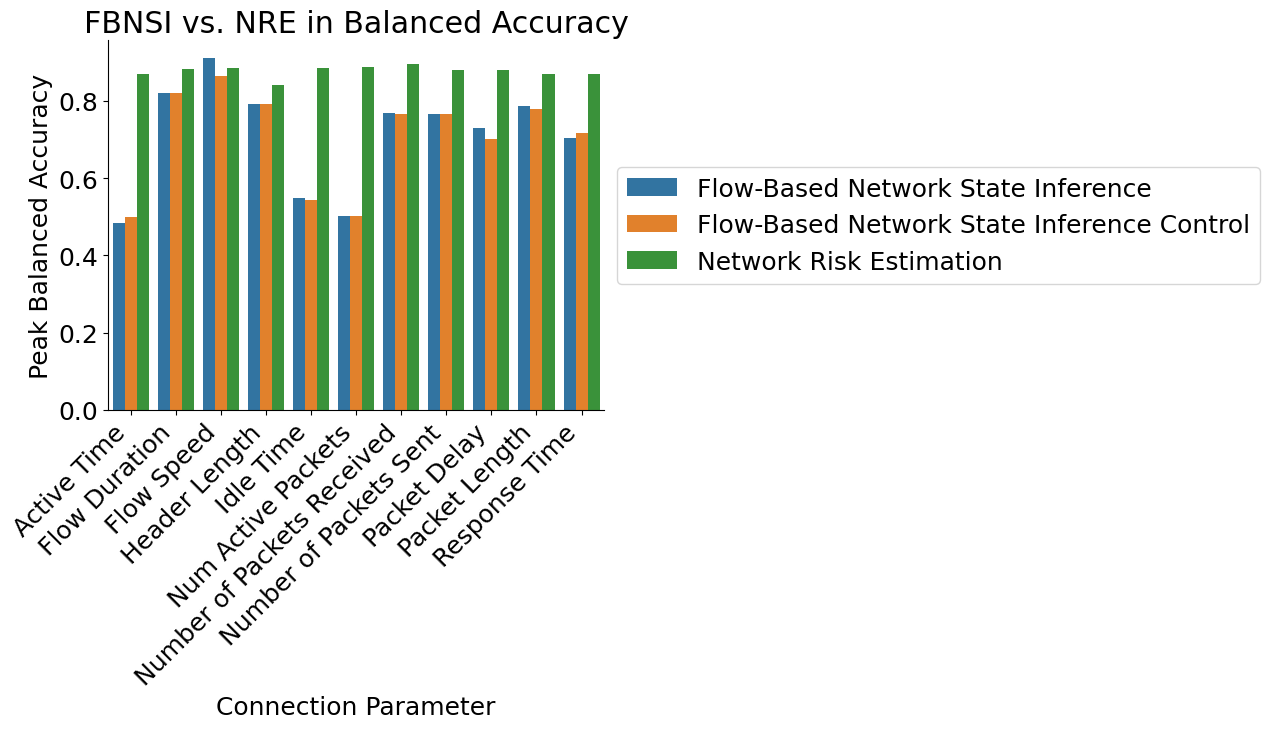

In [130]:
fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True)
print(file_addr)

# Miscellaneous

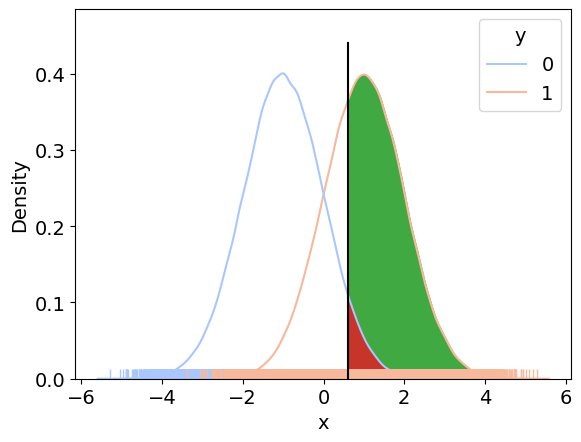

In [187]:
from scipy.stats import norm

from_sample = True
N = 100_000
plot_op, plot_thr = True, True
t = 0.6
plt.rcParams.update({'font.size': 14})

if not from_sample:
    xs1 = np.linspace(-4.5, 4.5, 2000)
    xs0 = xs1
    pdf0 = norm.pdf(xs0, -1, 1)
    pdf1 = norm.pdf(xs1, 1, 1)
    
    plt.plot(xs0, pdf0, label='0', color="tab:blue")
    plt.plot(xs1, pdf1, label='1', color="tab:red")
    plt.xlabel('x')
    plt.legend()
    ax = plt.gca()
else:
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    
    sns.kdeplot(data=df, x="x", hue="y", palette="coolwarm", common_norm=False)
    sns.rugplot(data=df, x="x", hue="y", palette="coolwarm")#, clip_on=False, height=-.02,)
    ax = plt.gca()
    li1, li0 = ax.lines[0], ax.lines[1]
    xs0  = li0.get_data()[0]
    pdf0 = li0.get_data()[1]
    xs1  = li1.get_data()[0]
    pdf1 = li1.get_data()[1]

if plot_thr:
    ax.plot([t, t], [0, ax.get_ylim()[1]], 'k')
    
    if plot_op:
        # True Positive
        ind = xs1 > t
        plt.fill_between(xs1[ind], pdf1[ind], 0, color='tab:green', alpha=0.9)
        
        # False Positives
        ind = xs0 > t
        plt.fill_between(xs0[ind], pdf0[ind], color='tab:red', alpha=0.9)

        



Text(0, 0.5, 'TPR')

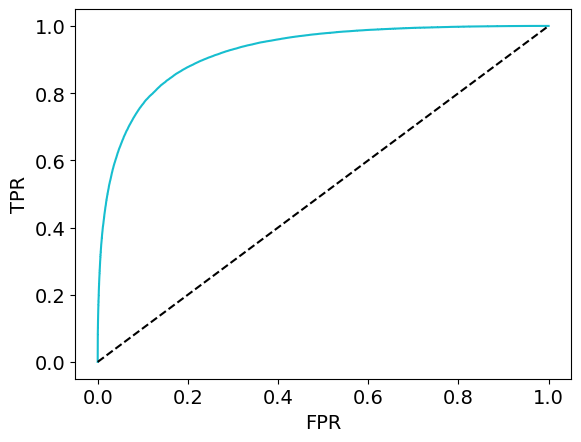

In [189]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
ax.plot(fpr, tpr, color='tab:cyan')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')
plt.xlabel('FPR')
plt.ylabel('TPR')

Text(0, 0.5, 'TPR')

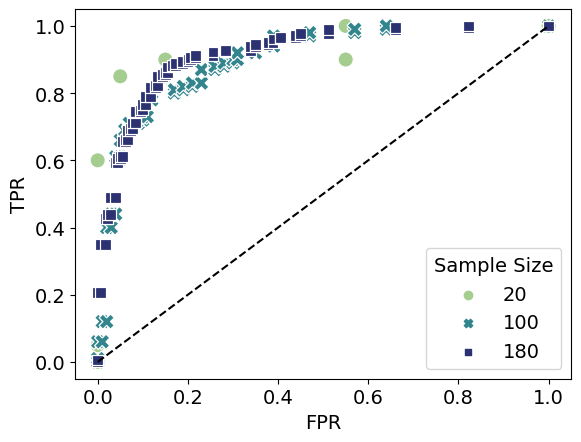

In [186]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
all_df = pd.DataFrame()
for N in np.arange(20, 200, 80):
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
    
    temp_df = pd.DataFrame({'FPR': fpr, 'TPR':tpr, 'Sample Size': N})
    all_df = pd.concat((all_df, temp_df))
    #ax.scatter(fpr, tpr, 'o', label=str(N))
    
sns.scatterplot(data=all_df, x='FPR', y='TPR', hue='Sample Size', style='Sample Size', s=120, ax=ax, palette='crest')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')    
plt.xlabel('FPR')
plt.ylabel('TPR')
#plt.legend()

In [161]:
np.arange(20, 30, 2)

array([20, 22, 24, 26, 28])